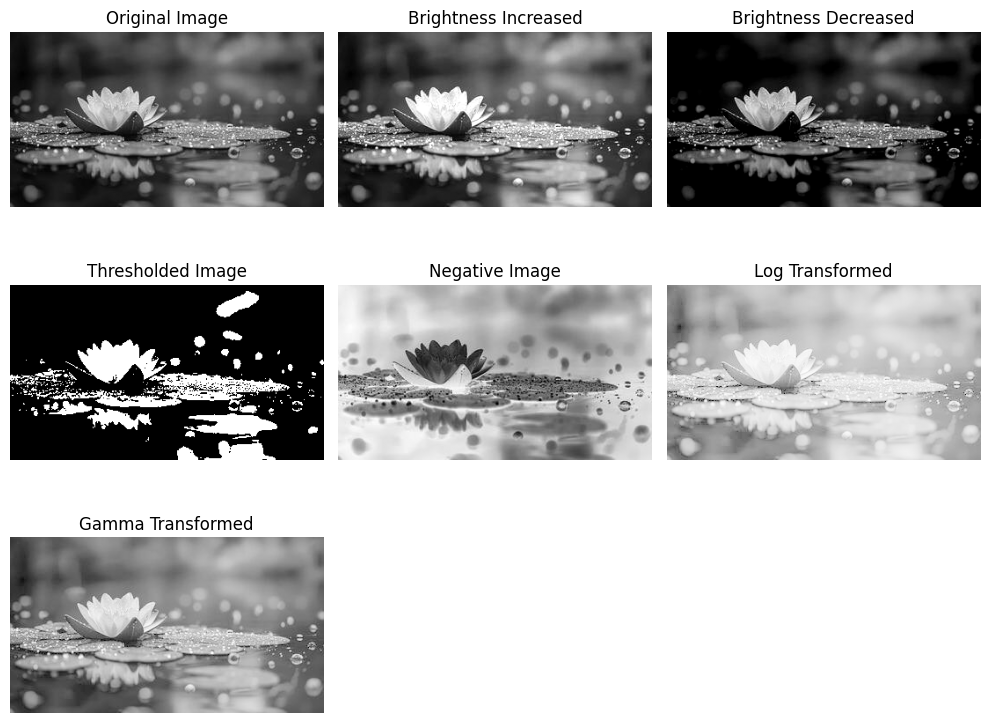

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Read the image (8-bit grayscale)
img = cv2.imread('/content/lotus.jpg', cv2.IMREAD_GRAYSCALE)
bright_increase = cv2.add(img, 50)  # adds 50 to pixel values
bright_decrease = cv2.subtract(img, 50)  # subtracts 50 from pixel values
_, threshold_img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)
negative_img = 255 - img

#Log Transformation
img_float = img.astype(float)
c = 255 / np.log(1 + np.max(img_float))
log_transformed = c * np.log(1 + img_float)
log_transformed = np.array(log_transformed, dtype=np.uint8)

#Power Law (Gamma) Transformation
gamma = 0.5  # change this to >1 for darker, <1 for brighter
gamma_transformed = np.array(255 * (img_float / 255) ** gamma, dtype=np.uint8)

#Display Results
titles = [
    'Original Image', 'Brightness Increased', 'Brightness Decreased',
    'Thresholded Image', 'Negative Image', 'Log Transformed', 'Gamma Transformed'
]
images = [
    img, bright_increase, bright_decrease,
    threshold_img, negative_img, log_transformed, gamma_transformed
]

plt.figure(figsize=(10, 8))
for i in range(7):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
